# EDA Agrupación por Macrogrupos

En este notebook se realizara un analisis exploratorio despues de las agrupaciones y de la limpeza de los datos a ver como se organizan los nuevos generos. En esta agrupación titulada **Macrogrupos** en esta si tiene otro enfoque en el cual se agrupan generos similares entre si.

| Grupo Resultante | Géneros Incluidos                                         | Justificación                                                                       |
|------------------|-----------------------------------------------------------|-------------------------------------------------------------------------------------|
| mainstream       | Pop, Dance, Rock, Alternative, Indie, R&B, Soul           | Música con alta rotación comercial y estructuras de producción similares.           |
| urban            | Hip-Hop, Rap, Reggaeton, Reggae, Ska                      | Géneros basados en ritmos síncopados, fuerte presencia de bajo y raíces callejeras. |
| acoustic         | Classical, Opera, Jazz, Blues, Folk, Country              | Música con mayor énfasis en instrumentos orgánicos y teoría musical tradicional.    |
| other            | Electronic, Soundtrack, Movie, Anime, Kids, World, Comedy | Contenido funcional, temático o que no encaja en las texturas anteriores.           |

In [1]:
import sys
import os
import importlib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import src.features.preprocessing_4classes as prep
importlib.reload(prep) 
df, x, y = prep.preprocessing()

df.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped_4
0,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False,other
1,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False,other
2,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False,other
3,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False,other
4,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False,other


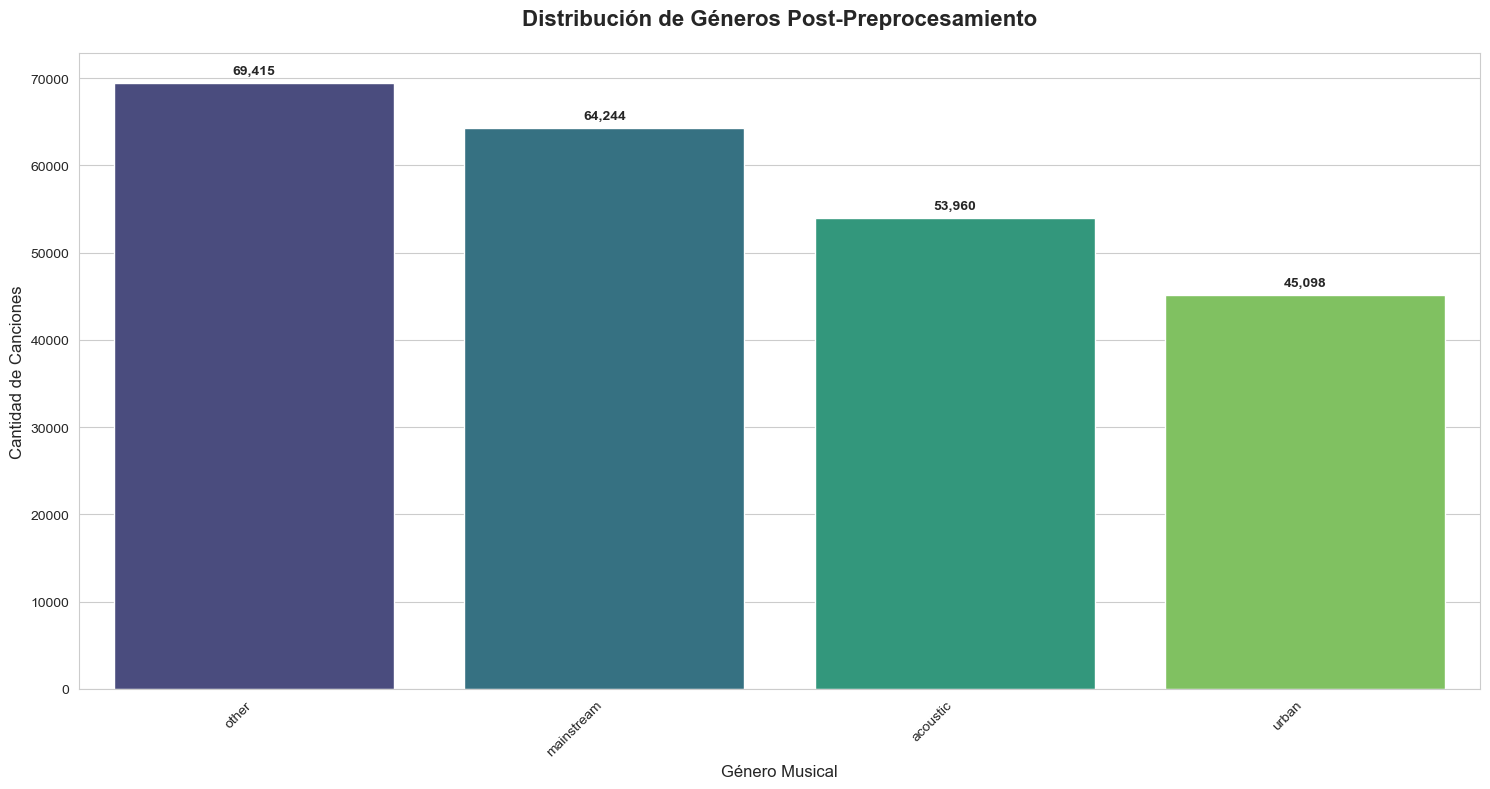

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = df['genre_grouped_4'].value_counts()

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    
plt.title('Distribución de Géneros Post-Preprocesamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [5]:
stats_despues = {
    'Num. Clases': df['genre_grouped_4'].nunique(),
    'Mínimo muestras': df['genre_grouped_4'].value_counts().min(),
    'Máximo muestras': df['genre_grouped_4'].value_counts().max(),
    'Promedio por clase': df['genre_grouped_4'].value_counts().mean()
}

stats_despues

{'Num. Clases': 4,
 'Mínimo muestras': 45098,
 'Máximo muestras': 69415,
 'Promedio por clase': np.float64(58179.25)}

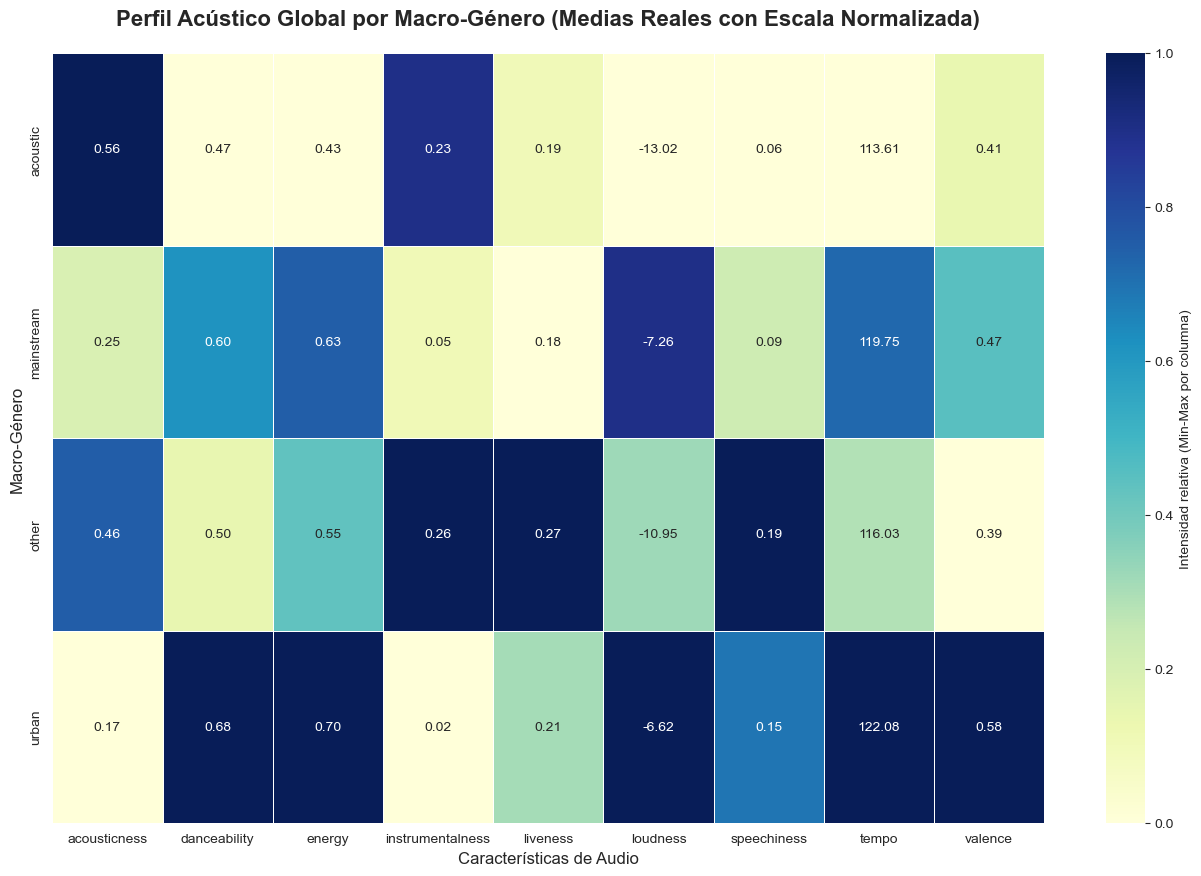


--- Análisis de Compactación (Desviación Estándar) ---


,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
genre_grouped_4,,,,,,,,,,
acoustic,15.648,0.377,0.181,0.282,0.354,0.172,7.359,0.056,31.045,0.268
mainstream,10.480,0.272,0.145,0.201,0.162,0.144,3.077,0.089,28.758,0.228
other,17.041,0.377,0.190,0.290,0.376,0.256,6.605,0.296,31.692,0.265
urban,16.619,0.192,0.152,0.170,0.114,0.175,2.596,0.119,31.624,0.234


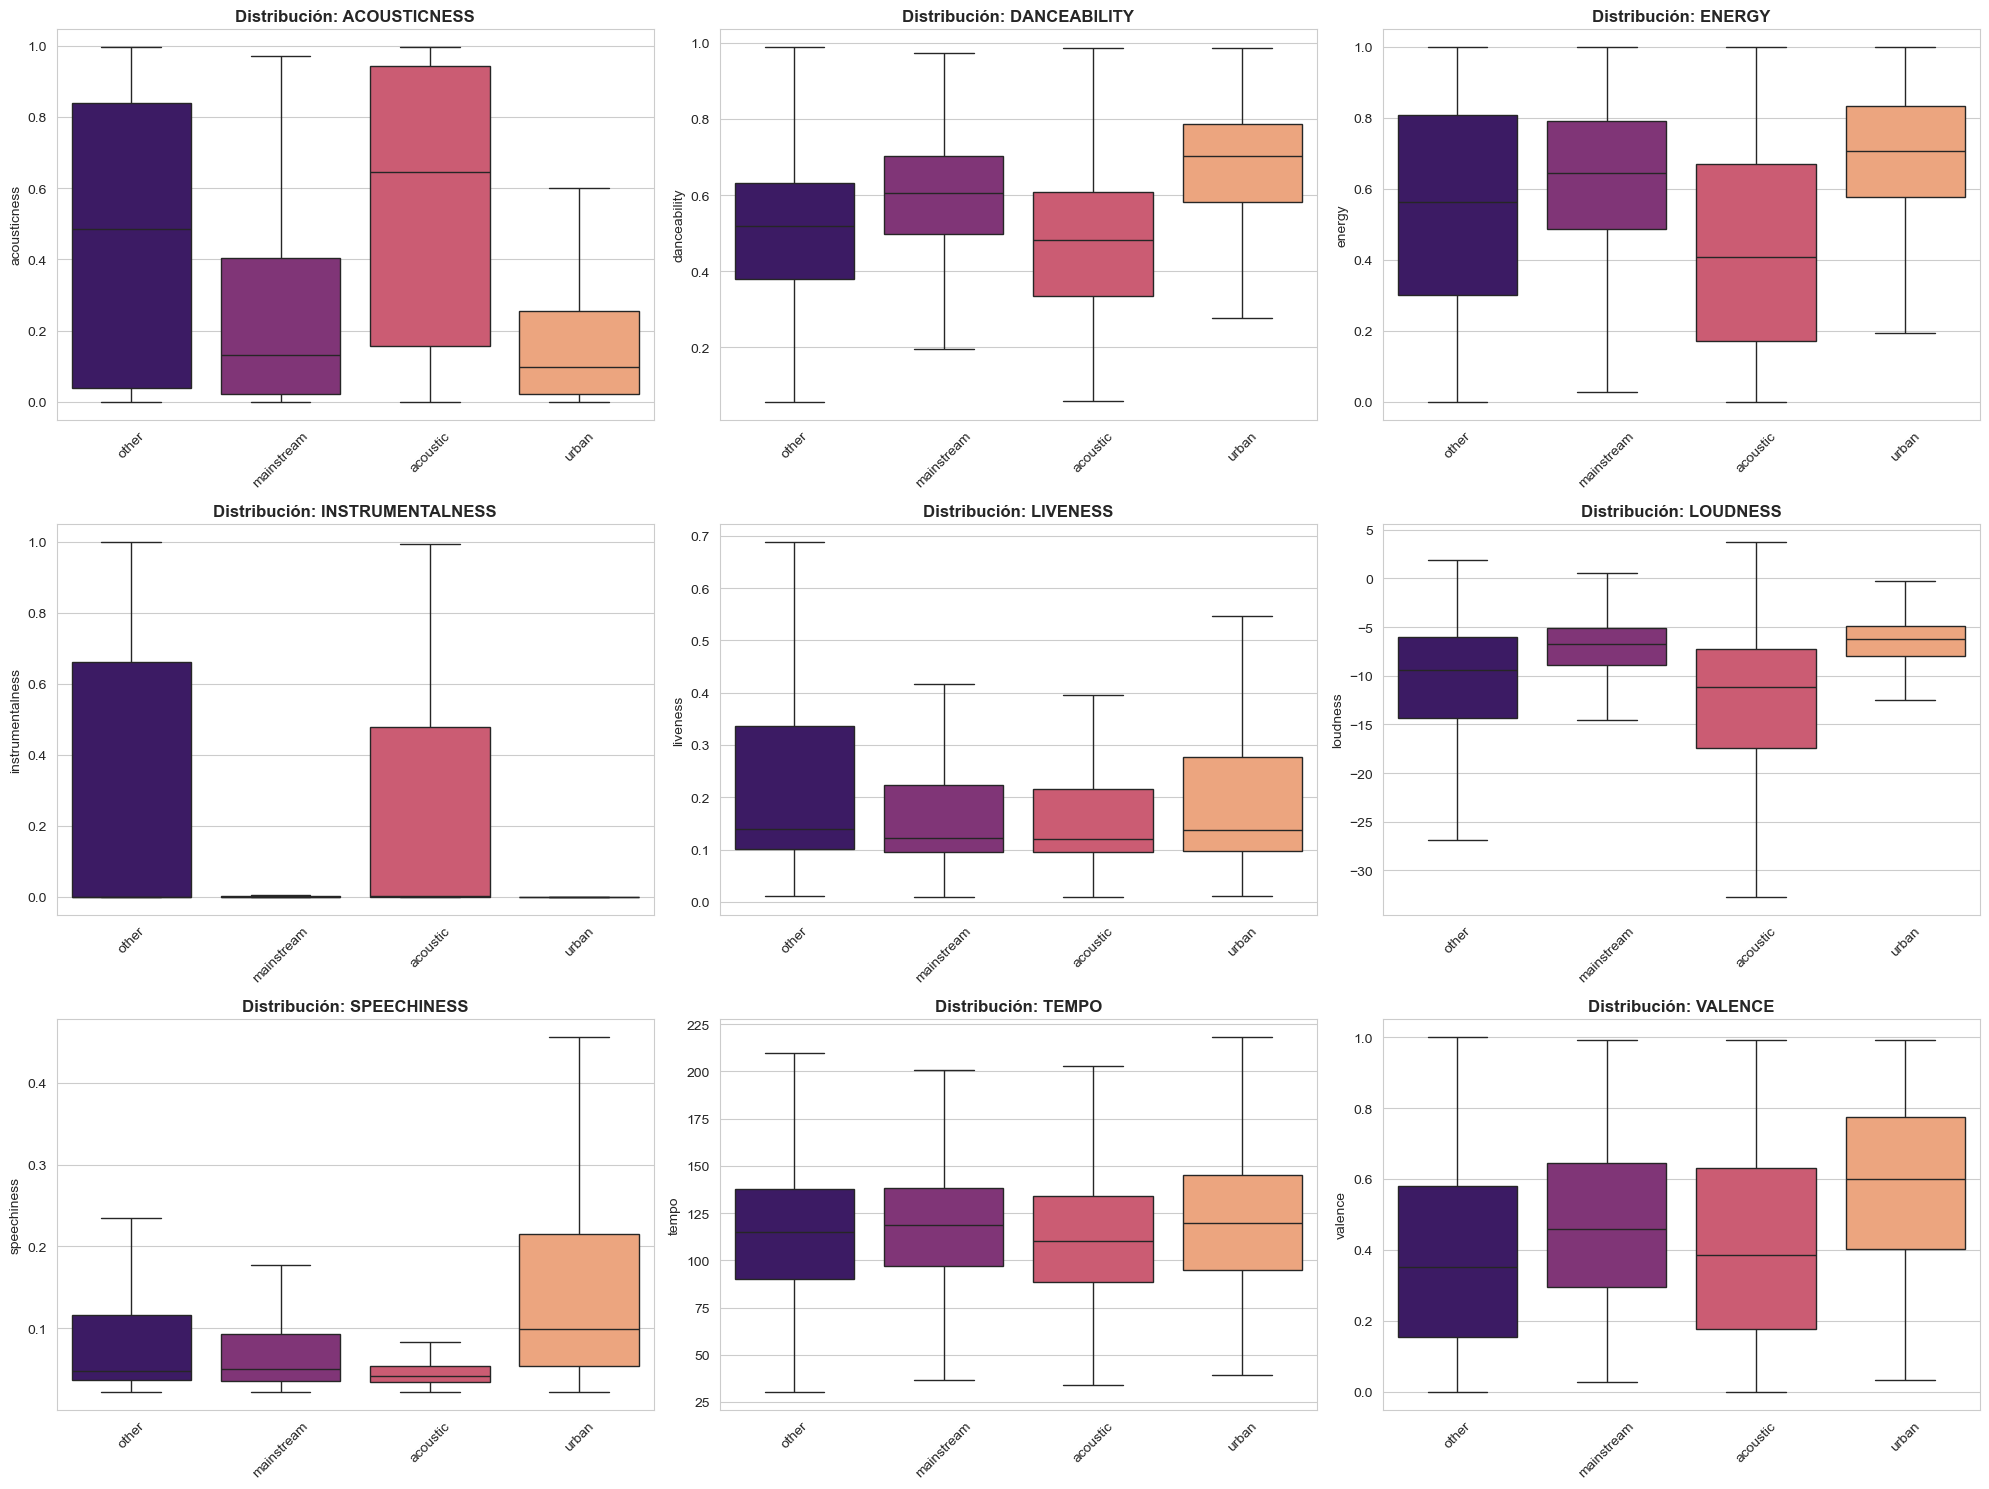

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Matriz de correlación para las variables numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['duration_ms', 'key', 'mode', 'time_signature', 'popularity']:
    if col in cols_numericas: cols_numericas.remove(col)
perfil_medios = df.groupby('genre_grouped_4')[cols_numericas].mean()
perfil_norm = (perfil_medios - perfil_medios.min()) / (perfil_medios.max() - perfil_medios.min())

plt.figure(figsize=(16, 10))
sns.heatmap(perfil_norm, 
            annot=perfil_medios,
            fmt=".2f", 
            cmap='YlGnBu', 
            linewidths=.5,
            cbar_kws={'label': 'Intensidad relativa (Min-Max por columna)'})

plt.title('Perfil Acústico Global por Macro-Género (Medias Reales con Escala Normalizada)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Macro-Género', fontsize=12)
plt.xlabel('Características de Audio', fontsize=12)
plt.show()

# Tablas de desviaciones estándar por macro-género

print("\n--- Análisis de Compactación (Desviación Estándar) ---")
display(perfil_std.round(3))


# Boxplots com respecto a 'genre_grouped_4' para cada variable numérica

n_cols = 3
n_rows = (len(cols_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(x='genre_grouped_4', y=col, data=df, ax=axes[i], palette='magma', showfliers=False)
    axes[i].set_title(f'Distribución: {col.upper()}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

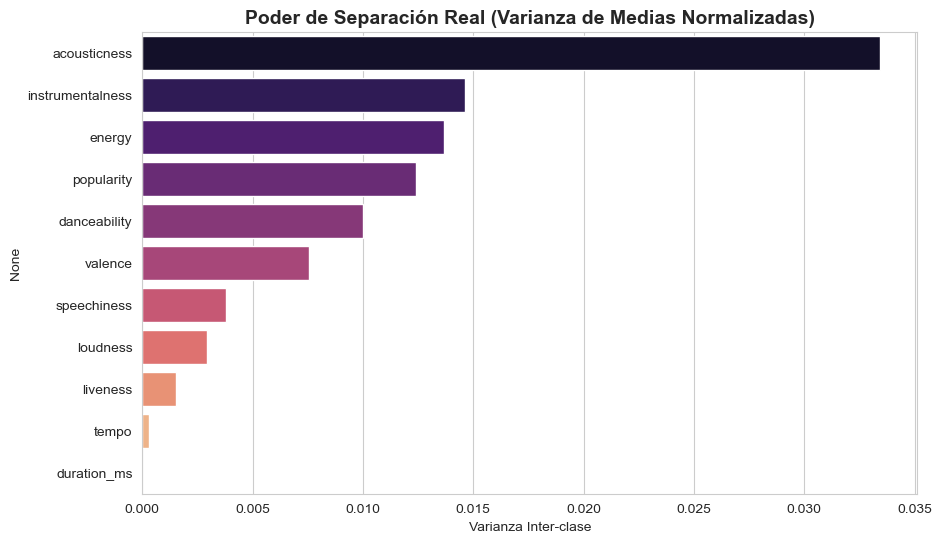

acousticness        0.033452
instrumentalness    0.014614
energy              0.013654
popularity          0.012401
danceability        0.009993
valence             0.007560
speechiness         0.003807
loudness            0.002933
liveness            0.001532
tempo               0.000316
duration_ms         0.000008
dtype: float64


In [14]:
from sklearn.preprocessing import MinMaxScaler


cols_cuantitativas = df.select_dtypes(include=[np.number]).columns.tolist()

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_cuantitativas]), columns=cols_cuantitativas)
df_scaled['genre_grouped_4'] = df['genre_grouped_4'].values

ranking_separacion = df_scaled.groupby('genre_grouped_4').mean().var().sort_values(ascending=False)

# 4. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_separacion.values, y=ranking_separacion.index, palette='magma')
plt.title('Poder de Separación Real (Varianza de Medias Normalizadas)', fontsize=14, fontweight='bold')
plt.xlabel('Varianza Inter-clase')
plt.show()

print(ranking_separacion)